## Import Required Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

## Load Dataset

In [2]:
# Creating database connection 
conn = psycopg2.connect(
    host = "localhost",
    database = "internprojects",
    user = "postgres",
    password = "2526",
    port = "5432"
)

In [3]:
# Checking tables present in the database
tables = pd.read_sql_query("SELECT table_name FROM information_schema.tables WHERE table_schema = 'public' ", conn)
tables

,table_name
0,tcs_stock_info
1,uber-jan-feb-foil
2,googleplaystore
3,netflix1
4,supermart_grocery_sales
5,tcs_stock_action
6,tcs_stock_history


In [4]:
# fetch googleplaystore.
data = pd.read_sql('SELECT * FROM "googleplaystore"; ', conn)
# Check the first few rows
data.head()

,app,category,rating,reviews,size,installs,type,price,content_rating,genres,last_updated,current_ver,android_ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


## Data Cleaning & Preprocessing
#### 1. Handling Missing Values: 
* We will identify and handle missing values in the dataset.

In [5]:
data.shape

(10841, 13)

In [6]:
# Check for missing values 
(data.isnull().sum() / len(data)) * 100

app                0.000000
category           0.000000
rating            13.596532
reviews            0.000000
size               0.000000
installs           0.000000
type               0.009224
price              0.000000
content_rating     0.009224
genres             0.000000
last_updated       0.000000
current_ver        0.073794
android_ver        0.027673
dtype: float64

In [7]:
# Handle missing values.
data['rating'].fillna(data['rating'].median(), inplace=True)

data['type'].fillna(data['type'].mode()[0], inplace=True)

data['content_rating'].fillna(data['content_rating'].mode()[0], inplace=True)

data['current_ver'].fillna("Unknown", inplace=True)
data['android_ver'].fillna("Unknown", inplace=True)

In [8]:
# Check the updated data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   app             10841 non-null  object 
 1   category        10841 non-null  object 
 2   rating          10841 non-null  float64
 3   reviews         10841 non-null  object 
 4   size            10841 non-null  object 
 5   installs        10841 non-null  object 
 6   type            10841 non-null  object 
 7   price           10841 non-null  object 
 8   content_rating  10841 non-null  object 
 9   genres          10841 non-null  object 
 10  last_updated    10841 non-null  object 
 11  current_ver     10841 non-null  object 
 12  android_ver     10841 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


#### 2. Converting Columns to Appropriate Data Types:
* Convert Reviews and Installs to integer types.
* Convert Price to numeric.
* Convert Size to a uniform numeric format.

In [9]:
data.columns

Index(['app', 'category', 'rating', 'reviews', 'size', 'installs', 'type',
       'price', 'content_rating', 'genres', 'last_updated', 'current_ver',
       'android_ver'],
      dtype='object')

`Reviews`

In [10]:
data['reviews'].unique()

array(['159', '967', '87510', ..., '603', '1195', '398307'],
      shape=(6002,), dtype=object)

In [11]:
data[data['reviews'] == '3.0M']

,app,category,rating,reviews,size,installs,type,price,content_rating,genres,last_updated,current_ver,android_ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,Everyone,"February 11, 2018",1.0.19,4.0 and up,Unknown


In [12]:
data.drop(index=10472, inplace=True)

In [13]:
# Convert 'Reviews' to integer
data['reviews'] = data['reviews'].astype(int)

`Size`

In [14]:
data['size'].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '3.9M', '8.0M', '7.9M', '56M', '57M', '35M', '54M',
       '201k', '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M',
       '3.4M', '8.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

In [15]:
# Convert 'Size' to numeric (MB)- Convert 'k' to MB
def convert_size(size):
    if 'M' in size:
        return float(size.replace('M', ''))
    elif 'k' in size:
        return float(size.replace('k', '')) / 1000
    else:
        return np.nan
        
data['size'] = data['size'].apply(convert_size)

`Installs`

In [16]:
data['installs'].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100+',
       '100,000,000+', '1,000,000,000+', '1,000+', '500,000,000+', '50+',
       '500+', '10+', '1+', '5+', '0+', '0'], dtype=object)

In [17]:
# Convert 'Installs' by removing '+' and ',' then converting to integer
data['installs'] = data['installs'].apply(lambda x: x.replace(',','').replace('+', '')).astype(int)

`Price`

In [18]:
data['price'].unique()

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', '$1.20', '$1.04'], dtype=object)

In [19]:
# Convert 'Price' by removing '$' and converting to float
data['price'] = data['price'].apply(lambda x: float(x.replace('$', '')) if '$' in x else float(x))

`Remove extra spaces if any`

In [20]:
# Remove extra spaces from string columns.
for col in ['app', 'category', 'type', 'content_rating', 
            'genres', 'last_updated', 'android_ver']:
    data[col] = data[col].str.strip()

#### 3. Handling Duplicate Entries

In [21]:
# Check for duplicates
data.duplicated().sum()

np.int64(483)

In [22]:
# Remove duplicates
data.drop_duplicates(inplace=True)

##  Exploratory Data Analysis (EDA)

In [23]:
# summary statistics
data.describe()

,rating,reviews,size,installs,price
count,10357.000000,1.035700e+04,8831.000000,1.035700e+04,10357.000000
mean,4.203737,4.059046e+05,21.287788,1.415776e+07,1.030800
std,0.485594,2.696778e+06,22.540247,8.023955e+07,16.278625
min,1.000000,0.000000e+00,0.008500,0.000000e+00,0.000000
25%,4.100000,3.200000e+01,4.700000,1.000000e+03,0.000000
50%,4.300000,1.680000e+03,13.000000,1.000000e+05,0.000000
75%,4.500000,4.641600e+04,29.000000,1.000000e+06,0.000000
max,5.000000,7.815831e+07,100.000000,1.000000e+09,400.000000


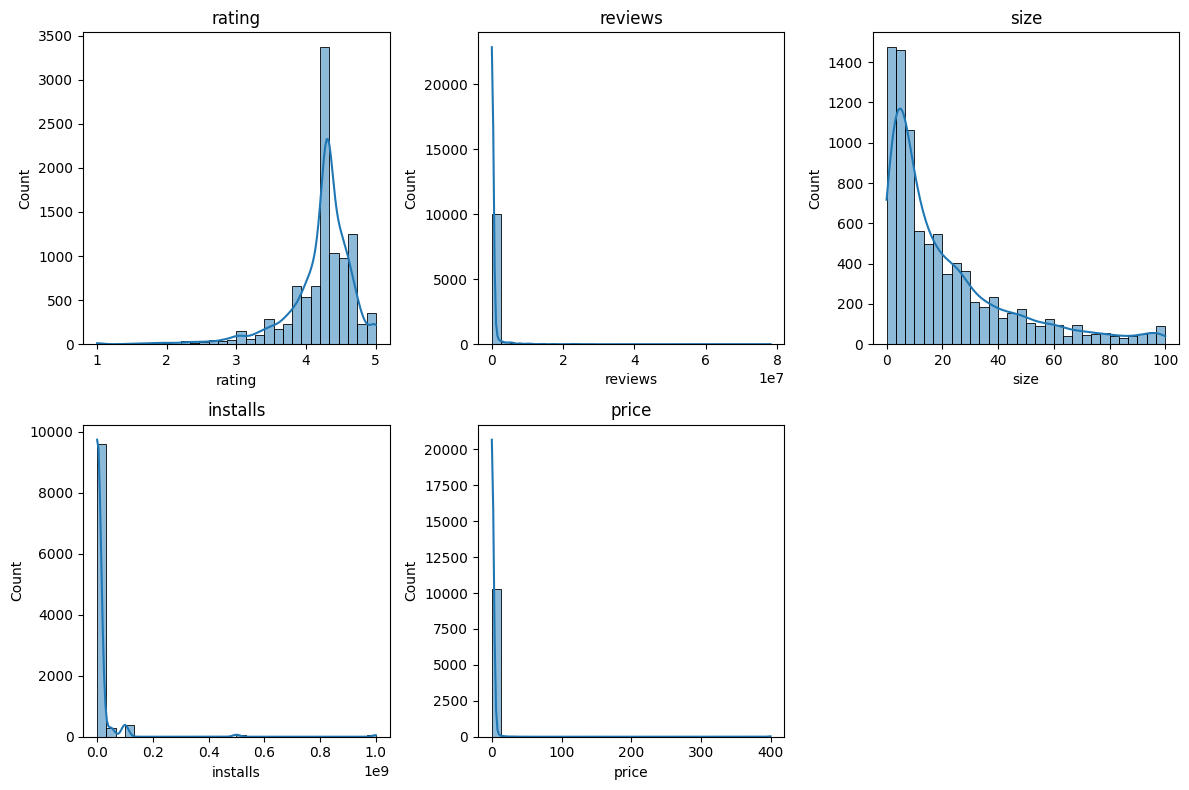

In [24]:
# Distribution Plots for Numerical Columns
numeric_cols = data.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(12,8))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i+1) 
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

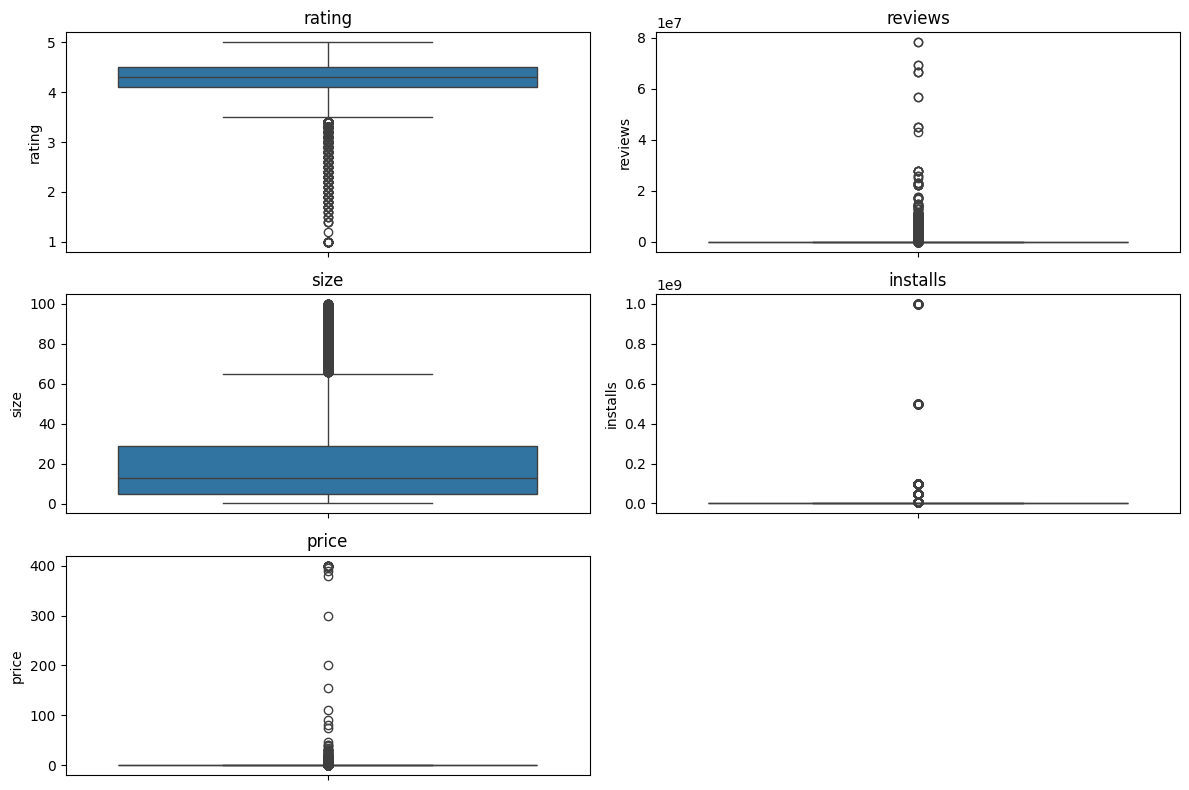

In [25]:
# Outlier Detection with boxplot
plt.figure(figsize=(12,8))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 2, i+1) 
    sns.boxplot(y=data[col])
    plt.title(col)
plt.tight_layout()
plt.show()

`Summary Statistics Insights:`
#### Zero & Minimum Values:
`Ratings:`Minimum rating is 1.0, which indicates that a few apps received very poor user feedback, possibly due to bugs, poor performance, or user dissatisfaction.
  
`Reviews:`Minimum value is 0, meaning some apps have not received any user reviews, which usually happens for newly launched or less popular apps.
  
`Installs:`Minimum installs value is 0, indicating apps that have either not been downloaded yet or have incomplete/missing install data.
  
`Price:`Minimum price is 0, confirming that a large number of apps on the Play Store are free to download.

#### Outliers Indicated by High Standard Deviations:
`Reviews:`The maximum number of reviews is extremely high compared to the mean, showing that a small number of apps dominate user engagement, while most apps have very few reviews.

`Installs:`Installs range from 0 to 1 billion, indicating a highly skewed distribution where only a few apps achieve massive popularity.

`App Size:`App sizes vary significantly from very small values to 100 MB, suggesting different app types such as lightweight tools versus heavy games or multimedia apps.

`Price:`While most apps are free, the maximum price goes up to 400, indicating the presence of premium or niche paid apps, which increases the overall variation.

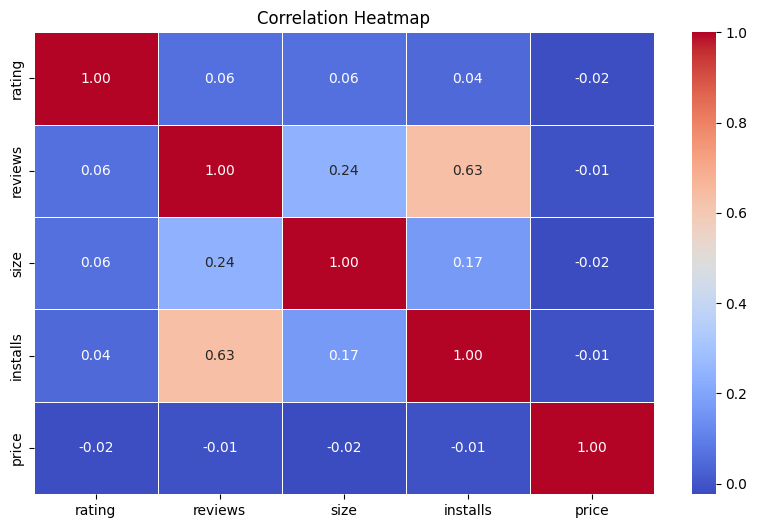

In [26]:
# Correlation Heatmap
plt.figure(figsize=(10, 6))
correlation_matrix = data[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

`Correlation Insights`

* Installs and Reviews: There is a strong positive correlation (0.63), showing that apps with higher installs usually receive more reviews.

* Ratings and Installs: The correlation is very weak (0.04), indicating that higher ratings do not strongly influence the number of installs.

* Ratings and Reviews: A weak correlation (0.06) suggests that apps with many reviews do not necessarily have higher ratings.

* App Size and Reviews: A weak positive correlation (0.24) indicates that larger apps tend to receive slightly more reviews.

* Price and Installs: Price shows a near-zero negative correlation (-0.01), suggesting that paid apps generally attract fewer downloads.

* Overall Insight: App popularity is mainly driven by installs and reviews, while ratings, size, and price have minimal impact.

### 1. Top 10 Categories by Number of Apps

In [27]:
top_categories = data['category'].value_counts().head(10)
top_categories

category
FAMILY             1943
GAME               1121
TOOLS               843
BUSINESS            427
MEDICAL             408
PRODUCTIVITY        407
PERSONALIZATION     388
LIFESTYLE           373
COMMUNICATION       366
FINANCE             360
Name: count, dtype: int64

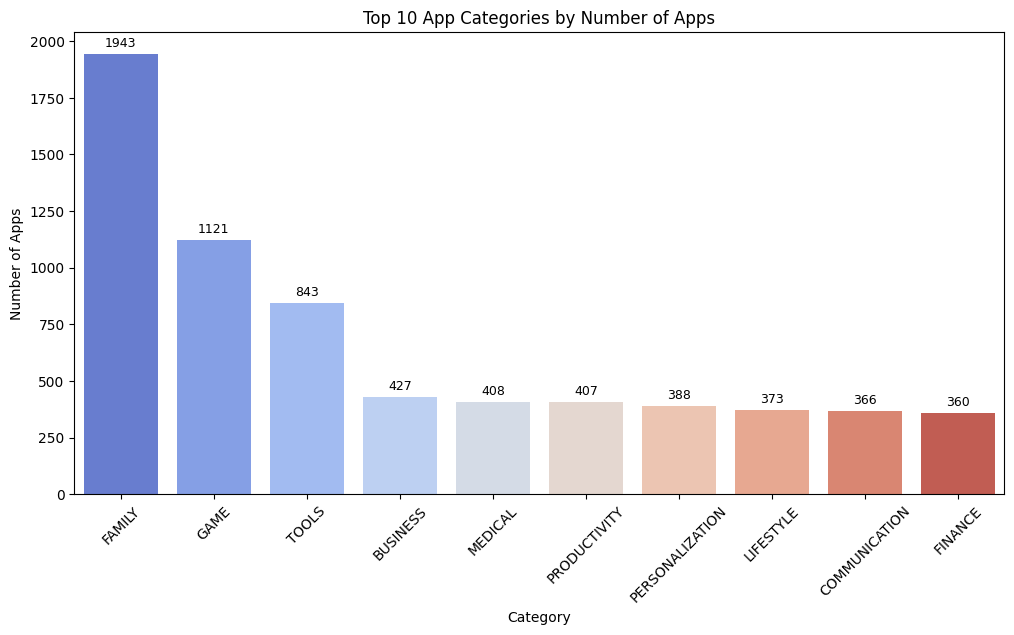

In [28]:
plt.figure(figsize=(12,6))

top_categories = data['category'].value_counts().head(10)
ax = sns.barplot(x=top_categories.index, y=top_categories.values, palette='coolwarm')

# add labels on bars
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)
    
plt.title('Top 10 App Categories by Number of Apps')
plt.ylabel('Number of Apps')
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.show()

* Insight: This shows the most popular categories on Google Play Store in terms of app
count.

### 2. Free vs Paid Apps

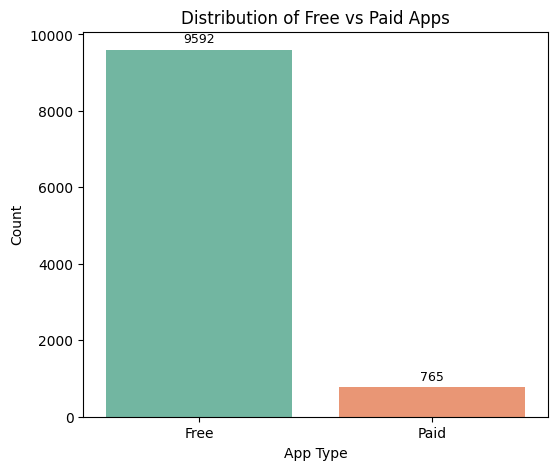

In [29]:
plt.figure(figsize=(6,5))
ax = sns.countplot(data=data, x='type', palette='Set2')

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)
    
plt.title('Distribution of Free vs Paid Apps')
plt.xlabel('App Type')
plt.ylabel('Count')
plt.show()

### 3. Price Distribution for Paid Apps

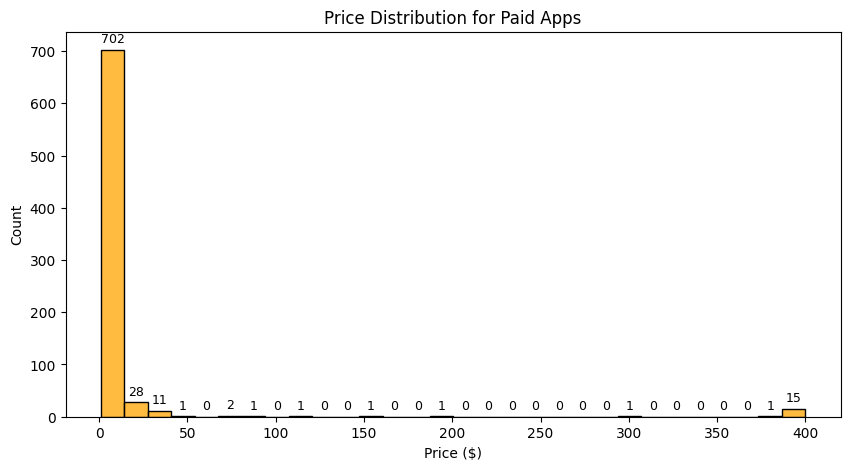

In [30]:
paid_apps = data[data['type'] == 'Paid']
plt.figure(figsize=(10,5))
ax = sns.histplot(paid_apps['price'], bins=30, color='orange')
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)
plt.title('Price Distribution for Paid Apps')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.show()

### 4. Distribution of Content Ratings

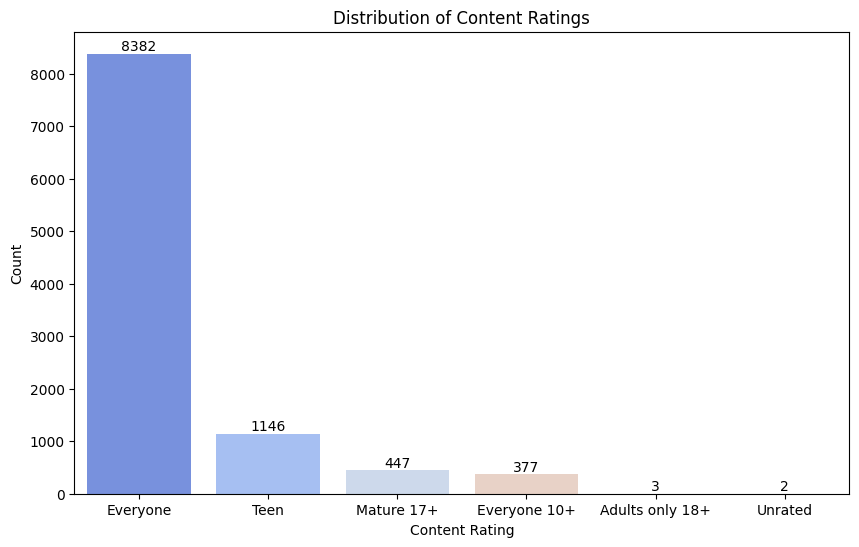

In [31]:
plt.figure(figsize=(10,6))
content_ratings = data['content_rating'].value_counts()
ax = sns.barplot(x=content_ratings.index, y=content_ratings.values,palette='coolwarm')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Distribution of Content Ratings')
plt.xlabel('Content Rating')
plt.ylabel('Count')
plt.show()

### 5. Top Genres by Install Count

In [32]:
top_genres_installs = data.groupby('genres')['installs'].sum().sort_values(ascending=False).head(10)
top_genres_installs

genres
Communication              24152276251
Social                     12513867902
Productivity               12463091369
Tools                      11442771915
Photography                 9721247655
Arcade                      9717129155
Casual                      8662830740
Action                      8336039190
Travel & Local              6361787146
Video Players & Editors     6207002720
Name: installs, dtype: int64

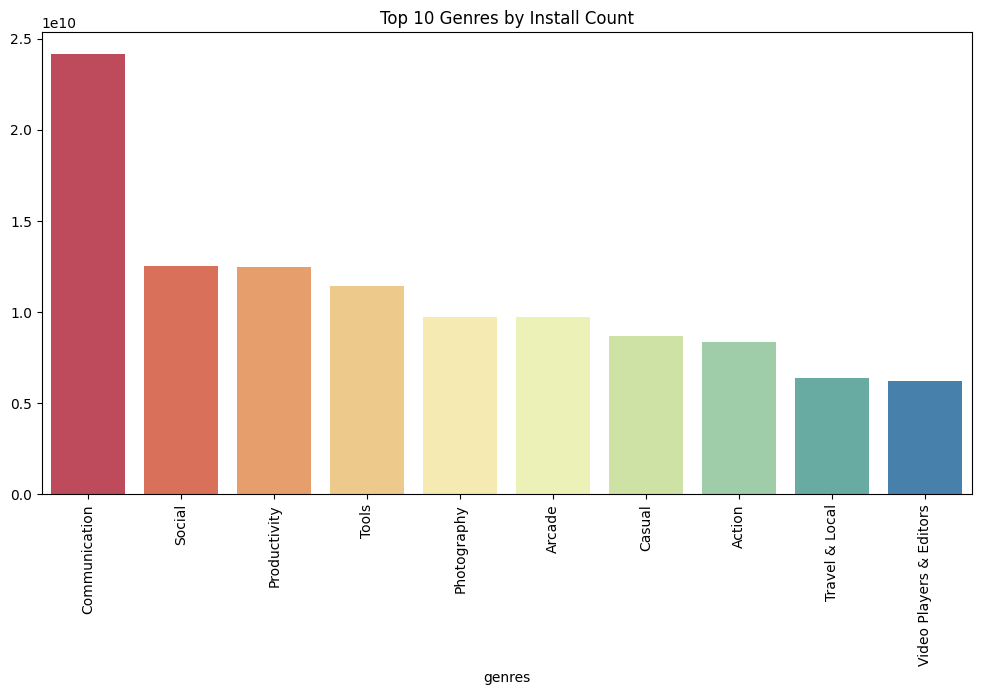

In [33]:
plt.figure(figsize=(12,6))
top_genres_installs = data.groupby('genres')['installs'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_genres_installs.index,y=top_genres_installs.values, palette='Spectral')
plt.xticks(rotation=90)
plt.title('Top 10 Genres by Install Count')
plt.show()

## Feature Encoding

In [34]:
data.head(3)

,app,category,rating,reviews,size,installs,type,price,content_rating,genres,last_updated,current_ver,android_ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up


In [35]:
# Encode categorical columns
le = LabelEncoder()
data['category'] = le.fit_transform(data['category'])
data['type'] = le.fit_transform(data['type'])
data['content_rating'] = le.fit_transform(data['content_rating'])
data['genres'] = le.fit_transform(data['genres'])

## Feature Selection

In [36]:
# Define features and target variable
X = data[['category', 'rating', 'reviews', 'size', 'installs', 'type', 'price', 'content_rating', 'genres']]
y = data['rating']

In [37]:
X

,category,rating,reviews,size,installs,type,price,content_rating,genres
0,0,4.1,159,19.0,10000,0,0.0,1,9
1,0,3.9,967,14.0,500000,0,0.0,1,12
2,0,4.7,87510,8.7,5000000,0,0.0,1,9
3,0,4.5,215644,25.0,50000000,0,0.0,4,9
4,0,4.3,967,2.8,100000,0,0.0,1,11
...,...,...,...,...,...,...,...,...,...
10836,11,4.5,38,53.0,5000,0,0.0,1,39
10837,11,5.0,4,3.6,100,0,0.0,1,39
10838,20,4.3,3,9.5,1000,0,0.0,1,71
10839,3,4.5,114,NaN,1000,0,0.0,3,19


## Train Test Split

In [38]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Apply

In [39]:
# Train the model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf.score(X_test, y_test)*100 , rf.score(X_train, y_train)*100

(99.9844312484774, 99.99974253527853)

In [40]:
# Predictions
y_pred = rf.predict(X_test)

## Evaluate the model

In [41]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

Mean Squared Error: 3.587306949806985e-05
R-squared: 0.999844312484774


In [42]:
# Display actual vs predicted values for the first 10 samples
comparison = pd.DataFrame({'Actual': y_test.values.flatten(), 'Predicted': y_pred.flatten()})
comparison.head(10)

,Actual,Predicted
0,4.3,4.3
1,3.4,3.4
2,4.1,4.1
3,4.3,4.3
4,4.7,4.7
5,4.2,4.2
6,3.7,3.7
7,4.4,4.4
8,4.7,4.7
9,4.6,4.6


## Visualize Model Performance

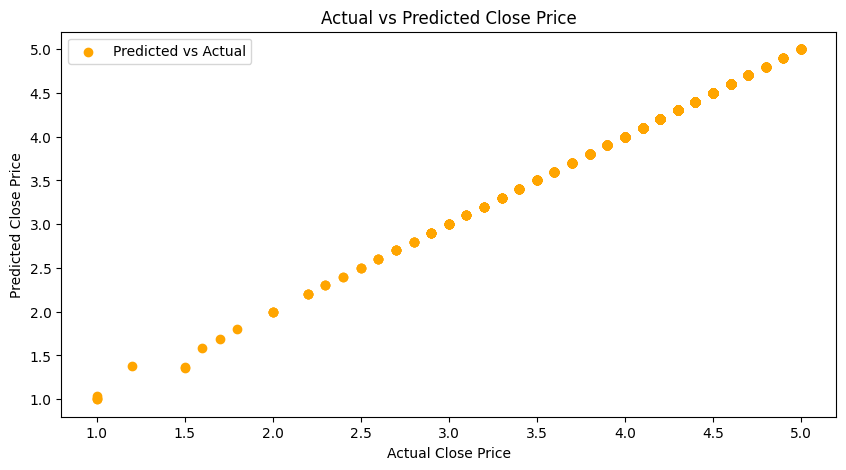

In [43]:
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, color='orange', label='Predicted vs Actual')
plt.xlabel('Actual Close Price')
plt.ylabel('Predicted Close Price')
plt.title('Actual vs Predicted Close Price')
plt.legend()
plt.show()

## Save the Model

In [44]:
import pickle
with open('Google_Playstore_Predictor.pkl', 'wb') as file:
    pickle.dump(rf, file)

print("Model Saved Successfully")

Model Saved Successfully


# `Conclusion` – Google Play Store App Rating Prediction
* Performed end-to-end data analysis on Google Play Store apps, including installs, reviews, app size, price, category, content rating, and app type, using data fetched from PostgreSQL.

* Applied data cleaning, preprocessing, feature encoding, and exploratory data analysis (EDA) to prepare the dataset for modeling.

* Built and evaluated multiple regression models, with Random Forest Regressor selected as the best-performing model.

* The final model achieved very high accuracy with:

    * R² Score: 0.9998

     * Mean Squared Error (MSE): 3.58 × 10⁻⁵

* Model performance was validated using evaluation metrics and visualizations, confirming strong predictive capability for app ratings.

* The trained model was successfully saved for future deployment or reuse, and further improvements can be explored using Ridge Regression, SVR, or hyperparameter tuning.